In [36]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

df = pd.read_csv(
    r"C:\Users\AMINE JBR\Downloads\Conception-d-un-Data-Warehouse-et-Tableaux-de-Bord-pour-l-Analyse-du-March-Immobilier---Darkom.ma-main\data\raw\darkom-annonces.csv"
)

df.columns = df.columns.str.strip().str.lower()

# date
df["date_publication"] = pd.to_datetime(
    df["date_publication"],
    errors="coerce"
)

# int columns
col_int = [
    "surface",
    "nb_chambres",
    "nb_salles_bain",
    "etage"
]

for col in col_int:
    df[col] = (
        pd.to_numeric(df[col], errors="coerce")
        .round()   
        .astype("Int64")
    )
duplicate = df[df.duplicated(subset="annonce_id", keep=False)]
duplicate = duplicate.sort_values(by="annonce_id")

df = df.sort_values(by="date_publication", ascending=False)
df = df.drop_duplicates(subset="annonce_id", keep="first")
df.info()

<class 'pandas.DataFrame'>
Index: 1500 entries, 415 to 1498
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   annonce_id          1500 non-null   str           
 1   date_publication    1424 non-null   datetime64[us]
 2   titre               1500 non-null   str           
 3   ville               1500 non-null   str           
 4   quartier            1085 non-null   str           
 5   type_bien           1462 non-null   str           
 6   transaction         1462 non-null   str           
 7   prix                1500 non-null   float64       
 8   surface             1500 non-null   Int64         
 9   nb_chambres         1371 non-null   Int64         
 10  nb_salles_bain      1397 non-null   Int64         
 11  etage               1268 non-null   Int64         
 12  annee_construction  1297 non-null   float64       
dtypes: Int64(4), datetime64[us](1), float64(2), str(6)
memory usag

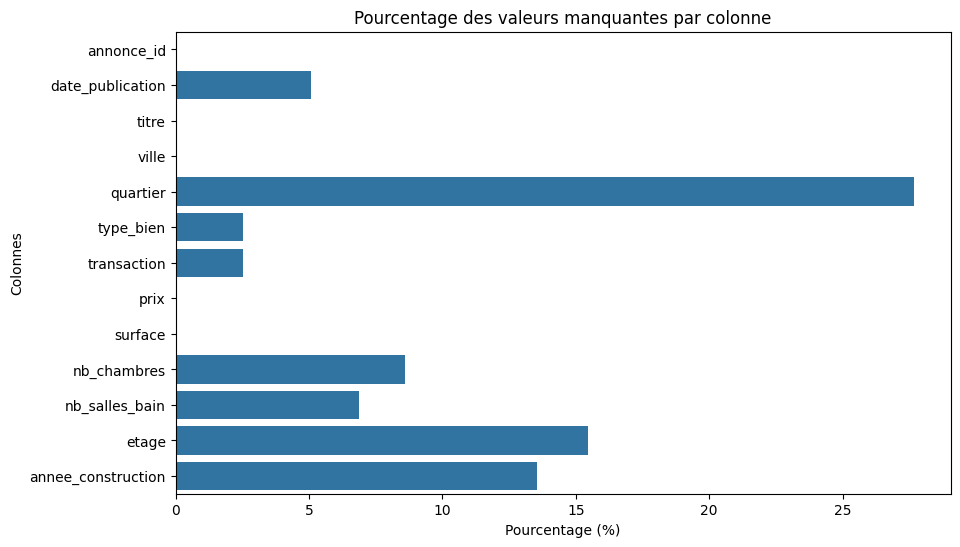

In [37]:
v_manque=df.isnull().sum()/df.shape[0]*100
v_manque
plt.figure(figsize=(10,6))

sns.barplot(
    x=v_manque.values,
    y=v_manque.index
)

plt.title("Pourcentage des valeurs manquantes par colonne")
plt.xlabel("Pourcentage (%)")
plt.ylabel("Colonnes")

plt.show()